In [1]:
# infercnv_metrics.ipynb - plot metrics (AUROC and AUPRC) of inferCNV CNA prediction.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from matplotlib.patches import Patch

In [3]:
root_dir = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/cna_prediction/1r1n1t/vary_tumor_prop'
out_dir = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/cna_prediction/1r1n1t/vary_tumor_prop/analysis/cna_prediction/infercnv'
tool = 'infercnv'
with_ref = 'noref'

## Merge metrics from multiple experiments into one single file.

In [4]:
run_id_list = sorted([d for d in os.listdir(root_dir) if d.endswith('t') and d != '997n3t'])
run_id_list

['100n900t',
 '10n990t',
 '300n700t',
 '30n970t',
 '500n500t',
 '700n300t',
 '900n100t',
 '970n30t',
 '990n10t']

In [5]:
dat = None
for run_id in run_id_list:
    print("processing '%s' ..." % run_id)
    run_dir = os.path.join(root_dir, run_id)
    df_run = None
    for cna_type in ('gain', 'loss', 'loh'):
        df2 = None
        for metric in ('auroc', 'auprc'):
            metric_fn = os.path.join(run_dir, 'cna_prediction/%s/%s/2_metric/metric.%s.%s.tsv' % \
                                    (with_ref, cna_type, cna_type, metric))
            if not os.path.exists(metric_fn):
                print("[W] file '%s' does not exist!" % metric_fn)
                continue
            df1 = pd.read_csv(metric_fn, sep = '\t')
            if df2 is None:
                df2 = df1
            else:
                assert np.all(df2['tool'] == df1['tool'])
                df2 = df2.merge(df1, on = 'tool', how = 'left')
        if df2 is None:
            continue
        df2['cna_type'] = cna_type
        if df_run is None:
            df_run = df2
        else:
            df_run = pd.concat([df_run, df2], ignore_index = True)
    if df_run is None:
        continue
    df_run['run_id'] = run_id
    if dat is None:
        dat = df_run
    else:
        dat = pd.concat([dat, df_run], ignore_index = True)
    print("dat shape: %s" % str(dat.shape))
dat.head()

processing '100n900t' ...
dat shape: (7, 5)
processing '10n990t' ...
[W] file '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/cna_prediction/1r1n1t/vary_tumor_prop/10n990t/cna_prediction/noref/loh/2_metric/metric.loh.auroc.tsv' does not exist!
[W] file '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/cna_prediction/1r1n1t/vary_tumor_prop/10n990t/cna_prediction/noref/loh/2_metric/metric.loh.auprc.tsv' does not exist!
dat shape: (11, 5)
processing '300n700t' ...
dat shape: (18, 5)
processing '30n970t' ...
[W] file '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/cna_prediction/1r1n1t/vary_tumor_prop/30n970t/cna_prediction/noref/loh/2_metric/metric.loh.auroc.tsv' does not exist!
[W] file '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/cna_prediction/1r1n1t/vary_tumor_prop/30n970t/cna_prediction/noref/loh/2_metric/metric.loh.auprc.tsv' does not exist!
dat shape: (22, 5)
processing '500n500t' ...
dat shape: (29, 5)
processing '700n300t' ...
dat shap

,tool,AUROC,AUPRC,cna_type,run_id
0,CalicoST,0.957492,0.967939,gain,100n900t
1,CopyKat,0.468225,0.069811,gain,100n900t
2,inferCNV,0.568464,0.093314,gain,100n900t
3,CalicoST,0.856672,0.873985,loss,100n900t
4,CopyKat,0.323583,0.017076,loss,100n900t


In [6]:
dat['tool'] = dat['tool'].replace({'CopyKat':'CopyKAT', 'inferCNV':'InferCNV'})
dat.head()

,tool,AUROC,AUPRC,cna_type,run_id
0,CalicoST,0.957492,0.967939,gain,100n900t
1,CopyKAT,0.468225,0.069811,gain,100n900t
2,InferCNV,0.568464,0.093314,gain,100n900t
3,CalicoST,0.856672,0.873985,loss,100n900t
4,CopyKAT,0.323583,0.017076,loss,100n900t


In [7]:
dat = dat[dat['tool'] == 'InferCNV'].copy()
dat

,tool,AUROC,AUPRC,cna_type,run_id
2,InferCNV,0.568464,0.093314,gain,100n900t
5,InferCNV,0.618622,0.037737,loss,100n900t
8,InferCNV,0.500948,0.089014,gain,10n990t
10,InferCNV,0.504302,0.025275,loss,10n990t
13,InferCNV,0.583754,0.118762,gain,300n700t
16,InferCNV,0.636597,0.081008,loss,300n700t
19,InferCNV,0.507702,0.091285,gain,30n970t
21,InferCNV,0.512363,0.027027,loss,30n970t
24,InferCNV,0.659633,0.158245,gain,500n500t
27,InferCNV,0.771261,0.203713,loss,500n500t


In [8]:
metric_fn = os.path.join(out_dir, 'cna_prediction.%s.%s.metrics.tsv' % (tool, with_ref))
dat.to_csv(
    metric_fn,
    sep = '\t',
    index = False
)

In [9]:
dat

,tool,AUROC,AUPRC,cna_type,run_id
2,InferCNV,0.568464,0.093314,gain,100n900t
5,InferCNV,0.618622,0.037737,loss,100n900t
8,InferCNV,0.500948,0.089014,gain,10n990t
10,InferCNV,0.504302,0.025275,loss,10n990t
13,InferCNV,0.583754,0.118762,gain,300n700t
16,InferCNV,0.636597,0.081008,loss,300n700t
19,InferCNV,0.507702,0.091285,gain,30n970t
21,InferCNV,0.512363,0.027027,loss,30n970t
24,InferCNV,0.659633,0.158245,gain,500n500t
27,InferCNV,0.771261,0.203713,loss,500n500t


## Plot

In [10]:
dat = pd.read_csv(
    metric_fn,
    sep = '\t'
)
dat

,tool,AUROC,AUPRC,cna_type,run_id
0,InferCNV,0.568464,0.093314,gain,100n900t
1,InferCNV,0.618622,0.037737,loss,100n900t
2,InferCNV,0.500948,0.089014,gain,10n990t
3,InferCNV,0.504302,0.025275,loss,10n990t
4,InferCNV,0.583754,0.118762,gain,300n700t
5,InferCNV,0.636597,0.081008,loss,300n700t
6,InferCNV,0.507702,0.091285,gain,30n970t
7,InferCNV,0.512363,0.027027,loss,30n970t
8,InferCNV,0.659633,0.158245,gain,500n500t
9,InferCNV,0.771261,0.203713,loss,500n500t


In [11]:
dat['run_id_raw'] = dat['run_id']
dat['run_id'] = dat['run_id'].map({
    '10n990t':'99',
    '30n970t':'97',
    '100n900t':'90',
    '300n700t':'70',
    '500n500t':'50',
    '700n300t':'30',
    '900n100t':'10',
    '970n30t':'3',
    '990n10t':'1'
})
dat['run_id'] = pd.Categorical(
    dat['run_id'], 
    categories = [str(i) for i in (1, 3, 10, 30, 50, 70, 90, 97, 99)],
    ordered = True
)
dat

,tool,AUROC,AUPRC,cna_type,run_id,run_id_raw
0,InferCNV,0.568464,0.093314,gain,90,100n900t
1,InferCNV,0.618622,0.037737,loss,90,100n900t
2,InferCNV,0.500948,0.089014,gain,99,10n990t
3,InferCNV,0.504302,0.025275,loss,99,10n990t
4,InferCNV,0.583754,0.118762,gain,70,300n700t
5,InferCNV,0.636597,0.081008,loss,70,300n700t
6,InferCNV,0.507702,0.091285,gain,97,30n970t
7,InferCNV,0.512363,0.027027,loss,97,30n970t
8,InferCNV,0.659633,0.158245,gain,50,500n500t
9,InferCNV,0.771261,0.203713,loss,50,500n500t


In [12]:
def plot_metrics(df, metric, figsize = (9, 5), fontsize = 10, add_legend = True):
    """Plot a grouped stacked bar chart of metric values.
    
    Parameters:
    ----------
    df : pd.DataFrame
        Must contain columns: 'tool', 'AUROC', 'cna_type', 'run_id'.
        'cna_type' should have values: 'gain', 'loss', 'loh'.
    metric : {'AUROC', 'AUPRC'}
    figsize : tuple, optional
        Figure size (width, height). Default is (9, 5).
    
    Returns:
    -------
    fig, ax : matplotlib figure and axes
    """
    required_cols = {'tool', metric, 'cna_type', 'run_id'}
    if not required_cols.issubset(df.columns):
        raise ValueError(f"DataFrame must contain columns: {required_cols}")
    
    if not set(df['cna_type'].unique()).issubset({'gain', 'loss', 'loh'}):
        raise ValueError("cna_type must only contain 'gain', 'loss', 'loh'")
    
    # Ensure consistent ordering
    df = df.copy()
    df['cna_type'] = pd.Categorical(df['cna_type'], categories = ['gain', 'loss', 'loh'])
    df = df.sort_values(['run_id', 'tool', 'cna_type']).reset_index(drop = True)

    # Pivot to get metric value per (run_id, tool, cna_type)
    pivot = df.pivot_table(
        index = ['run_id', 'tool'],
        columns = 'cna_type',
        values = metric,
        fill_value = 0
    )

    # Extract unique groups
    run_ids = pivot.index.get_level_values('run_id').unique()
    tools = pivot.index.get_level_values('tool').unique()
    n_runs, n_tools = len(run_ids), len(tools)

    # Bar layout
    bar_width = 0.65 / n_tools
    x_centers = np.arange(n_runs)

    # Colors
    stack_colors = {'gain': '#D14050', 'loss': '#0078BB', 'loh': '#40B5A8'}
    tool_palette = [
        '#56B4E9',    # InferCNV
        '#E69F00',    # CopyKAT
        '#0072B2',    # Numbat
        '#F0E442',    # XClone
        '#D55E00'     # CalicoST
    ]
    tool_colors = [tool_palette[i % 100] for i in range(n_tools)]

    # Create plot
    fig, ax = plt.subplots(figsize = figsize)
    bottom = np.zeros((n_runs, n_tools))

    # Draw stacked bars
    for cna in ['gain', 'loss']:
        for i, tool in enumerate(tools):
            heights = [
                pivot.loc[(run, tool), cna] if (run, tool) in pivot.index else 0
                for run in run_ids
            ]
            x_pos = x_centers + i * bar_width
            ax.bar(
                x_pos,
                heights,
                bottom = bottom[:, i],
                width = bar_width,
                color = stack_colors[cna],
                edgecolor = 'black',
                linewidth = 0.5,
                label = cna if i == 0 else None
            )
            bottom[:, i] += heights
    
    y_star = 0.12
    for i, tool in enumerate(tools):
        for j, run in enumerate(run_ids):
            has_output = True
            if (run, tool) in pivot.index:
                h = np.sum([pivot.loc[(run, tool), cna] for cna in ('gain', 'loss')])
                if h <= 0:
                    has_output = False
            else:
                has_output = False
            x_pos = x_centers[j] + i * bar_width
            if not has_output:
                ax.text(
                    x_pos, y_star,
                    '*', 
                    ha = 'center', va = 'top',
                    fontsize = fontsize,
                    color = 'black',
                    weight = 'bold'
                )

    # Main axis styling
    ax.set_xticks(x_centers + bar_width * (n_tools - 1) / 2)
    ax.set_xticklabels(run_ids)
    ax.set_xlabel('Tumor percentage (%)', fontsize = fontsize + 1)
    ax.set_ylabel(metric, fontsize = fontsize + 1)
    ax.set_xlim(0 - bar_width, n_runs - 1 + bar_width * n_tools)
    ax.set_ylim(0, 2.05)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Title (lowered to avoid top panel)
    #fig.suptitle('AUROC by Run, Tool, and CNA Type', y=0.95)

    if add_legend:
        # Legend for CNA types
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        d = {'gain':'Gain', 'loss':'Loss', 'loh':'LOH'}
        legend = fig.legend(
            by_label.values(), 
            [d[k] for k in by_label.keys()], 
            title = 'CNA Type', 
            loc = 'upper left',
            frameon = False,
            fontsize = fontsize,
            title_fontsize = fontsize + 1,
            alignment = 'left',
            bbox_to_anchor = (0.7, 0.95)
        )
        for patch in legend.get_patches():
            patch.set_edgecolor('none')

    plt.tight_layout()
    return fig, ax

### Plot AUROC

In [13]:
metric = 'AUROC'
df = dat[['tool', metric, 'cna_type', 'run_id']].copy()
df

,tool,AUROC,cna_type,run_id
0,InferCNV,0.568464,gain,90
1,InferCNV,0.618622,loss,90
2,InferCNV,0.500948,gain,99
3,InferCNV,0.504302,loss,99
4,InferCNV,0.583754,gain,70
5,InferCNV,0.636597,loss,70
6,InferCNV,0.507702,gain,97
7,InferCNV,0.512363,loss,97
8,InferCNV,0.659633,gain,50
9,InferCNV,0.771261,loss,50


/tmp/pbs.1790203.xomics/ipykernel_44651/2313894603.py:30: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


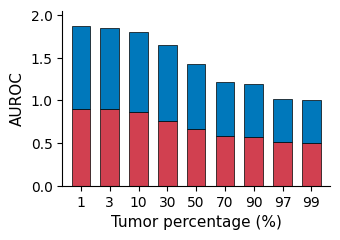

In [14]:
fig, ax = plot_metrics(df, metric = metric, figsize = (3.5, 2.5), fontsize = 10, add_legend = False)

In [15]:
fn = os.path.join(out_dir, 'cna_prediction.%s.%s.%s.png' % (tool, with_ref, metric))
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')

### Plot AUPRC

In [16]:
metric = 'AUPRC'
df = dat[['tool', metric, 'cna_type', 'run_id']].copy()
df

,tool,AUPRC,cna_type,run_id
0,InferCNV,0.093314,gain,90
1,InferCNV,0.037737,loss,90
2,InferCNV,0.089014,gain,99
3,InferCNV,0.025275,loss,99
4,InferCNV,0.118762,gain,70
5,InferCNV,0.081008,loss,70
6,InferCNV,0.091285,gain,97
7,InferCNV,0.027027,loss,97
8,InferCNV,0.158245,gain,50
9,InferCNV,0.203713,loss,50


/tmp/pbs.1790203.xomics/ipykernel_44651/2313894603.py:30: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


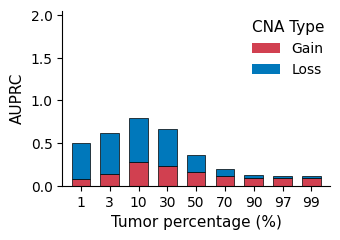

In [17]:
fig, ax = plot_metrics(df, metric = metric, figsize = (3.5, 2.5), fontsize = 10)

In [18]:
fn = os.path.join(out_dir, 'cna_prediction.%s.%s.%s.png' % (tool, with_ref, metric))
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')